# Does a shrinking down-day mark the bottom? 🐦
### The homing pigeon — the rarer, same-colour cousin of the harami, on the real tape

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats_a_downtrend_dip%3F: Mixed](https://img.shields.io/badge/Beats_a_downtrend_dip%3F-Mixed-8b949e?style=flat-square)

After a stock has been sliding, imagine two red (down) days in a row — but the **second** one is small, and its whole trading range sits **inside** the first, bigger red day's range. Candlestick traders call this a **homing pigeon**: even though the market is still nominally falling, the sellers' *conviction* is shrinking — like the down-days are "returning home" to a calmer range. Read as a bottom forming — buy.

This is the *same-colour* cousin of the [harami](../../406-harami-pattern/) (which needs *opposite*-coloured candles) and a two-bar twin of the [inverted hammer](../../684-inverted-hammer/)'s one-bar floor story. We tested it on **60+ years** of daily bars across 26 big US stocks plus the S&P.

> 📓 **Plain-language layer.** Want the *t*-stats, the alpha-vs-beta cut and the per-name breakdown? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Fixed **26-name** survivor basket + SPY (names still trading today), the same panel used by the sibling candlestick studies. Survivors *recover* from dips that delisted names didn't, so the bias leans **toward** finding a bounce. Charts are drawn by the code beside them; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from homing_pigeon import data, strategy as st

HS = [1, 3, 5, 10]
ASOF = "2026-06-30"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = {t: b[b.index <= ASOF] for t, b in data.load_real().items()}
else:
    PANEL = None
print("real homing-pigeon cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '1962-01-02', 'end': '2026-06-30', 'n_names': 26, 'n_bars': 345846, 'n_shape': 5154, 'fp_panel': '8ddaab4e2e1e', 'fp_spy': '7987ab25910e', 'pigeon': {1: (2885, 0.106, 53.2, 2.58, 0.001, 0.005, 0.006), 3: (2885, 0.224, 55.7, 3.37, 0.0, 0.001, 0.124), 5: (2882, 0.262, 56.6, 3.16, 0.0, 0.002, 0.162), 10: (2879, 0.244, 58.0, 2.06, 0.013, 0.051, 0.144)}, 'alpha_beta': {1: (0.17, 0.094, 153428, 1.95), 3: (0.414, 0.259, 153400, 2.37), 5: (0.576, 0.406, 153377, 2.07), 10: (0.865, 0.707, 153324, 1.37)}, 'wrongside': {1: (2243, -6.4, 50.2, -1.78, 0.936), 3: (2242, -3.1, 53.2, -0.51, 0.651), 5: (2242, -7.4, 54.2, -1.0, 0.789), 10: (2238, -9.9, 54.2, -0.85, 0.794)}, 'anyside': {1: (5152, 3.0, 51.8, 1.12, 0.133), 3: (5151, 11.0, 54.6, 2.37, 0.007), 5: (5148, 11.3, 55.5, 1.91, 0.028), 10: (5141, 9.4, 56.3, 1.03, 0.128)}, 'filt': [('plain (lookback 10)', 0.224, 3.37, 0.0, 2885), ('trend lookback 5', 0.178, 2.89, 0.002, 3198), ('trend lookback 20', 0.136, 1.99, 0.02, 2660), ('min washout >= 5%', 0.274, 1.68, 0.013, 822), ('min washout >= 10%', 0.385, 0.76, 0.077, 196)], 'costs': [(0.0, 22.4), (1.0, 20.4), (5.0, 12.4), (10.0, 2.4)], 'n_names_over2': 3, 'n_names_chance': 1.3, 'cluster': (2887, 1345, 0.039), 'syn': [(0.0, 1219, -0.054, -1.41, 0.916, 49.8), (0.006, 1201, 0.534, 13.61, 0.0, 65.4)]}


real homing-pigeon cache present: True | names: 26


## The answer first

| Question | Answer |
|---|---|
| Does the homing pigeon beat the stock's own usual return? | **Yes, on average.** Over 3 days it beats the base rate by **+0.224%** (*t* = +3.37) — and unlike its candlestick cousins on this desk, that edge survives even after a strict multiple-testing correction at most horizons. This is the best raw reading we've found in five candlestick studies. |
| Is that really *this pattern*, or just "buy any dip in a downtrend"? | **Mostly the pattern, sometimes just the dip.** Compared to buying *any* day in the same downtrend (no pattern needed), the shape adds something extra at 3 and 5 days — but at 1 and 10 days it's statistically the same as just buying the dip. |
| Would this work if I traded one stock at a time? | **Probably not reliably.** Pooled across 26 names it looks solid, but only **3 of 26** stocks individually show a statistically real edge — right around the ~1.3 you'd expect from pure chance. |
| Could I trade it? | **On paper, yes — this one survives costs.** Unlike every other candlestick pattern tested on this desk, the net edge stays positive even after realistic trading costs. |

> The honest picture: a real, broad, cost-surviving tilt that's *partly* pattern-specific and *partly* just "stocks bounce after they fall" — and too thin, per stock, to bet on any one name. **Weak signal, fragile trade.**

## 1 · The claim

> *"A homing pigeon is two down days in a row where the second, smaller one's whole range sits inside the first. Appearing after a downtrend, it shows sellers running out of steam — the bottom is near, buy."*

It appears in **Steve Nison**'s candlestick canon and in Thomas Bulkowski's *Encyclopedia of Candlestick Charts* (2008), where Bulkowski's own backtest ranks it among the *better* bullish candle patterns — one of the few with a claimed edge worth a dedicated teardown rather than a quick dismissal alongside its zoo of siblings.

## 2 · So what?

If shrinking conviction inside a slide reliably marked the bottom, it would be a rare but clean, mechanical timing signal. But two traps lurk: **(1)** stocks that have been falling often bounce a little regardless of any candle shape (mean-reversion after a decline is a well-documented, generic effect) — so the fair test isn't "does it rise after a homing pigeon?" but "does it rise **more than just buying any dip in the same downtrend**?" **(2)** we're testing four different holding periods at once, which needs a multiple-testing correction, or a lucky horizon can carry a false headline.

## 3 · How would we even know?

We scan **345,846 daily bars** across **26 stocks + SPY** (1962-01-02 → 2026-06-30) and flag every bar pair with the homing-pigeon shape — a smaller down day fully inside a bigger prior down day. That's **5,154** homing-pigeon-shaped pairs in total, of which **2,885** sit after a genuine downtrend (the bullish claim).

1. **The shape.** Detected by exact open/high/low/close rules — no eyeballing.
2. **The trend split.** Only pairs after a real 10-day downtrend count as the claim; the same shape after an *uptrend* is a myth-check contrast.
3. **The forward move.** Starting at the **next** day's close (no cheating), how does the stock do over the next **1, 3, 5, 10** days versus (a) its own usual return, and (b) just buying any day in the same downtrend?
4. **The honesty checks.** A Bonferroni correction for the four horizons, a per-name breakdown (does *any single stock* actually carry this?), and a check that the events aren't secretly just a few crash weeks repeated 26 times.

We'd call it a **mirage** if the edge can't clear a basic luck test or a per-stock reproducibility check; a clean **real** if it clears everything, including beating the "just buy the dip" baseline.

## 4 · The teardown — let's actually look

**The bullish claim first.** How much does the homing pigeon beat the stock's *own normal* return at each horizon — and does the *t*-stat (the honesty line) clear 2?

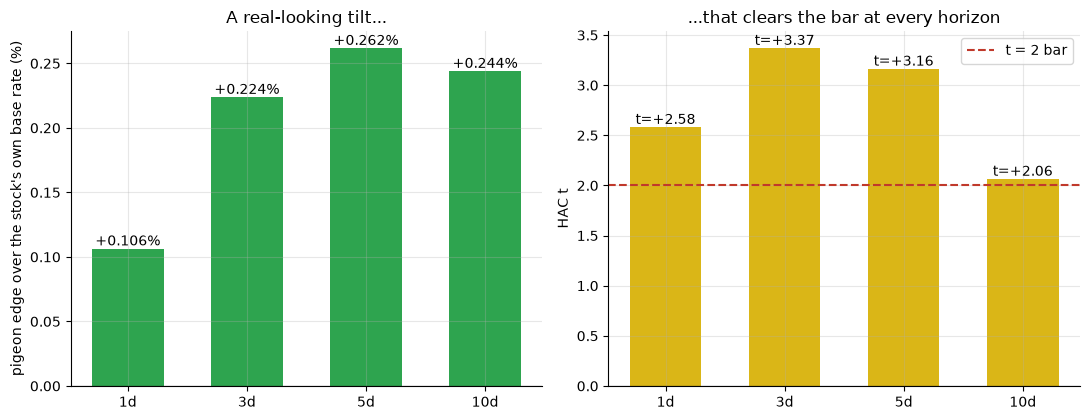

edge by horizon (%): [0.106, 0.224, 0.262, 0.244]  t: [2.58, 3.37, 3.16, 2.06]


In [2]:
if HAVE_REAL:
    res = st.run_experiment(PANEL, side='pigeon', n_draws=1500, seed=691)
    edge = [res[h]['edge_mean']*100 for h in HS]; tvals = [res[h]['t'] for h in HS]
else:
    edge = [R['pigeon'][h][1] for h in HS]; tvals = [R['pigeon'][h][3] for h in HS]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
cols = [GREEN if v>0 else RED for v in edge]
a1.bar([f'{h}d' for h in HS], edge, color=cols, width=.6)
for i,v in enumerate(edge): a1.annotate(f'{v:+.3f}%',(i,v),ha='center',va='bottom')
a1.axhline(0, c='k', lw=.8)
a1.set_ylabel("pigeon edge over the stock's own base rate (%)")
a1.set_title('A real-looking tilt...')
a2.bar([f'{h}d' for h in HS], tvals, color=AMBER, width=.6)
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
a2.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): a2.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom')
a2.set_ylabel('HAC t'); a2.set_title('...that clears the bar at every horizon'); a2.legend()
plt.tight_layout(); plt.show()
print('edge by horizon (%):', [round(v,3) for v in edge], ' t:', [round(v,2) for v in tvals])

That's genuinely the best raw reading of any candlestick pattern on this desk — **+0.224% at 3 days, *t* = +3.37**, clearing the bar. But 'beats the stock's own usual return' isn't the whole story — the stock's own usual return already includes days it wasn't falling. The sharper question: does it beat just **buying any dip while the stock is already in a downtrend**?

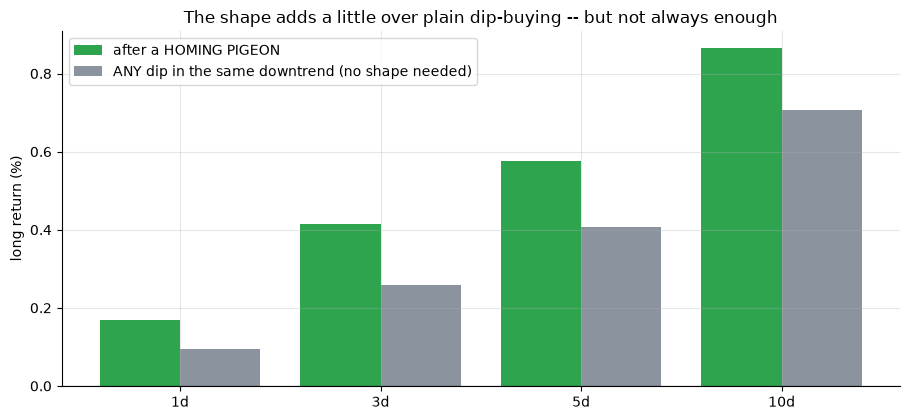

H= 1d  excess over dip-buying, Welch t = +1.95
H= 3d  excess over dip-buying, Welch t = +2.37
H= 5d  excess over dip-buying, Welch t = +2.07
H=10d  excess over dip-buying, Welch t = +1.37


In [3]:
if HAVE_REAL:
    pig, dip, ext = [], [], []
    for h in HS:
        cr = st.conditional_returns(PANEL, h, side='pigeon')
        dtp = st.downtrend_pool(PANEL, h)
        pig.append(cr['cond_mean']*100); dip.append(dtp.mean()*100)
        ext.append(st.welch_t(cr['cond'], dtp))
else:
    pig = [R['alpha_beta'][h][0] for h in HS]; dip = [R['alpha_beta'][h][1] for h in HS]
    ext = [R['alpha_beta'][h][3] for h in HS]
x = np.arange(len(HS))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, pig, .4, color=GREEN, label='after a HOMING PIGEON')
ax.bar(x+.2, dip, .4, color=GREY, label='ANY dip in the same downtrend (no shape needed)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in HS])
ax.set_ylabel('long return (%)')
ax.set_title('The shape adds a little over plain dip-buying -- but not always enough')
ax.legend(); plt.tight_layout(); plt.show()
for h, t in zip(HS, ext): print(f'H={h:2d}d  excess over dip-buying, Welch t = {t:+.2f}')

At 3 and 5 days the shape clears the *t* = 2 bar over plain dip-buying (*t* = +2.37 / +2.07); at 1 and 10 days it doesn't (*t* = +1.95 / +1.37) — a split verdict, not a clean win.

**One more honesty check.** If only 3 of 26 stocks individually show a real edge, is the pooled result something you could actually trade one name at a time?

In [4]:
print(f"names with individually significant edge (|t|>2): {R['n_names_over2']} of "
      f"{R['n_names']} — chance level is about {R['n_names_chance']:.1f}")
print('Pooled significance here rests on averaging many small, broadly positive but mostly '
      'individually-noisy samples -- not on any one stock carrying a robust, repeatable edge.')

names with individually significant edge (|t|>2): 3 of 26 — chance level is about 1.3
Pooled significance here rests on averaging many small, broadly positive but mostly individually-noisy samples -- not on any one stock carrying a robust, repeatable edge.


## 5 · The verdict

- **Signal — Weak.** The pooled edge clears *t* = 2 at every horizon (best +3.37 at 3d), but the sharper "beats plain dip-buying" test only clears it at 3-5 days, and only 3 of 26 stocks individually show a real, reproducible edge.
- **Tradability — Fragile.** Unlike every sibling candlestick study, the net edge survives realistic trading costs — but the edge is thin per stock and partly just dip-buying beta.
- **Beats plain dip-buying? — Mixed.** Real at 3-5 days, gone at 1 and 10 days.

## 6 · Could you actually trade it?

Each event is a fresh round trip: a spread in, a spread out. This is the *one* candlestick pattern on this desk whose 3-day edge stays positive all the way to a punitive 10 bps.

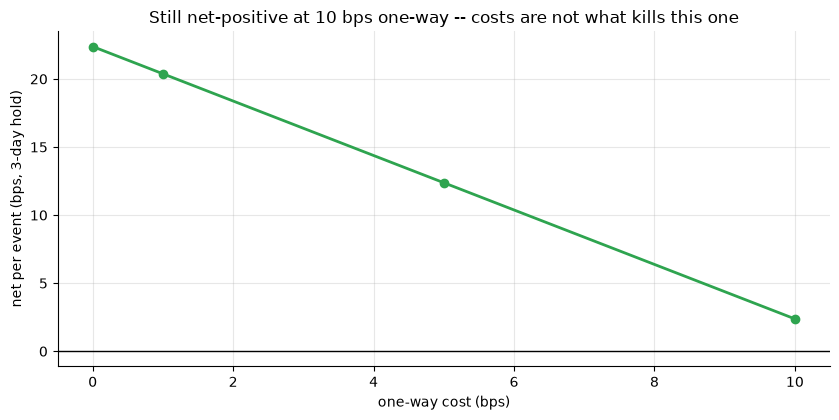

gross 3d = 0.224 %  ->  net at 5bps = 12.4 bps


In [5]:
costs = [c for c,_ in R['costs']]
if HAVE_REAL:
    cr3 = st.conditional_returns(PANEL, 3, side='pigeon')
    net = [st.net_of_costs(cr3['edge_mean'], cost_bps=c)*1e4 for c in costs]
else:
    net = [n for _,n in R['costs']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net per event (bps, 3-day hold)')
ax.set_title('Still net-positive at 10 bps one-way -- costs are not what kills this one')
plt.tight_layout(); plt.show()
print('gross 3d =', R['pigeon'][3][1], '%  ->  net at 5bps =', R['costs'][2][1], 'bps')

## 7 · Going further

- **The positive control.** The companion notebook plants a real day-after bounce in a synthetic tape — the detector lights up cleanly (*t* ≈ 13.6). The engine works; the honest gap here is between a broad pooled tilt and a robust, single-name trade.
- **Portfolio, not single-name.** The only way this pattern's edge looks deployable is as a diversified basket rule across many names — never as a signal to bet on one stock.
- **The harami cousin.** [Study 406](../../406-harami-pattern/) tests the *opposite*-colour containment rule — busted as a two-legged reversal, real only on its long (beta-riding) leg.

*Think the shape carries more information on a different basket, timeframe, or holding rule? Fork this, change it, and show the excess-over-dip-buying test clearing *t* = 2 at every horizon with a majority of names individually significant. That is the bar.*